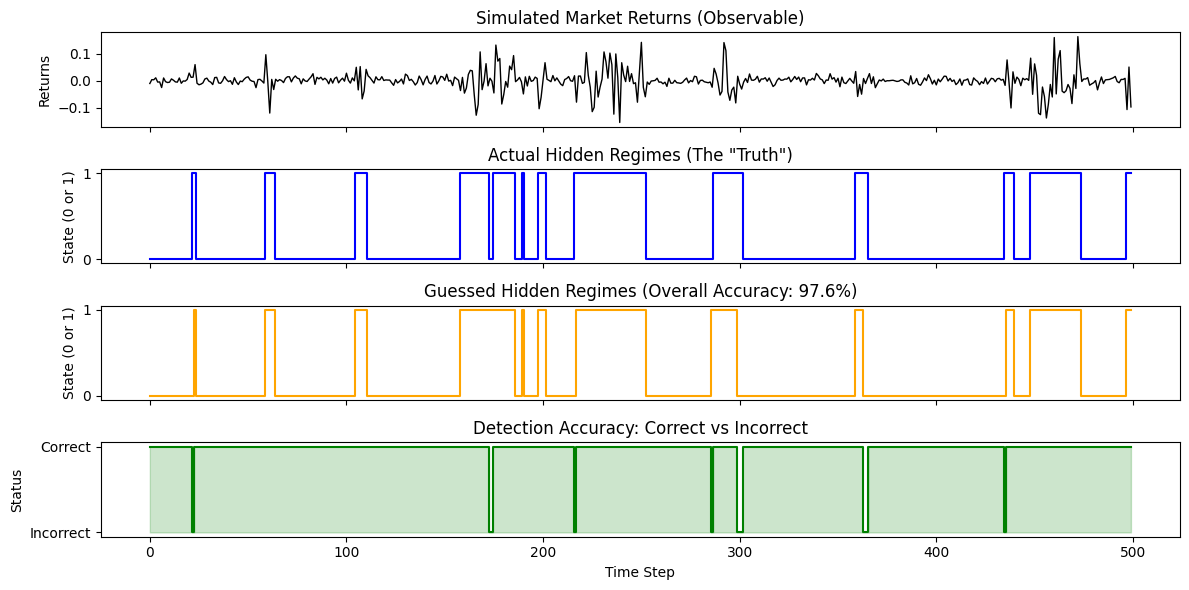

In [7]:
import numpy as np
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt

# ==========================================
# 1. DEFINE THE HMM 
# ==========================================
model = GaussianHMM(n_components=2, covariance_type="diag", n_iter=100)

model.transmat_ = np.array([[0.95, 0.05],  
                            [0.10, 0.90]]) 
model.means_ = np.array([[0.001], [-0.002]])
model.covars_ = np.array([[0.0001], 
                          [0.005]])
model.startprob_ = np.array([0.8, 0.2]) 

# ==========================================
# 2. SIMULATE THE DATA
# ==========================================
np.random.seed(42) 
X_returns, Z_hidden_states = model.sample(500)

# ==========================================
# 3. DETECTING THE STATES
# ==========================================
detective_model = GaussianHMM(n_components=2, n_iter=1000, random_state=42)
detective_model.fit(X_returns) 
guessed_states = detective_model.predict(X_returns)

# --- NEW: Fix potential Label Permutation (Flipping) ---
# If the accuracy is less than 50%, the labels are likely flipped
accuracy = np.mean(guessed_states == Z_hidden_states)
if accuracy < 0.5:
    aligned_guesses = 1 - guessed_states # Flips 0 to 1, and 1 to 0
else:
    aligned_guesses = guessed_states

# Create a boolean array where True (1) is correct, False (0) is incorrect
correct_guesses = (aligned_guesses == Z_hidden_states).astype(int)
final_accuracy_pct = np.mean(correct_guesses) * 100

# ==========================================
# 4. PLOTTING THE RESULTS (Now with 4 panels!)
# ==========================================
fig, axs = plt.subplots(4, 1, figsize=(12, 6), sharex=True)

# Plot 1: The observable returns
axs[0].plot(X_returns, color='black', linewidth=1)
axs[0].set_title('Simulated Market Returns (Observable)')
axs[0].set_ylabel('Returns')

# Plot 2: The actual hidden states
axs[1].step(range(len(Z_hidden_states)), Z_hidden_states, where='mid', color='blue')
axs[1].set_title('Actual Hidden Regimes (The "Truth")')
axs[1].set_ylabel('State (0 or 1)')
axs[1].set_yticks([0, 1])

# Plot 3: The aligned guessed states
axs[2].step(range(len(aligned_guesses)), aligned_guesses, where='mid', color='orange')
axs[2].set_title(f'Guessed Hidden Regimes (Overall Accuracy: {final_accuracy_pct:.1f}%)')
axs[2].set_ylabel('State (0 or 1)')
axs[2].set_yticks([0, 1])

# Plot 4: Correct vs Incorrect
axs[3].step(range(len(correct_guesses)), correct_guesses, where='mid', color='green')
axs[3].fill_between(range(len(correct_guesses)), 0, correct_guesses, color='green', step='mid', alpha=0.2)
axs[3].set_title('Detection Accuracy: Correct vs Incorrect')
axs[3].set_ylabel('Status')
axs[3].set_yticks([0, 1])
axs[3].set_yticklabels(['Incorrect', 'Correct'])
axs[3].set_xlabel('Time Step')

plt.tight_layout()
plt.show()

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# ==========================================
# 1. SIMULATE THE GROUND TRUTH
# ==========================================
np.random.seed(1) # Keeps results consistent
T = 5000

# AR(1) parameters (The Truth)
rho = np.array([0.2, 0.8])
sigma = np.array([0.5, 1.0])

# Transition matrix
P = np.array([
    [0.95, 0.05],
    [0.05, 0.95]
])

states = np.zeros(T, dtype=int)
y = np.zeros(T)

# Initial values
states[0] = np.random.choice([0,1])
y[0] = np.random.normal()

for t in range(1, T):
    # simulate next state
    states[t] = np.random.choice([0,1], p=P[states[t-1]])
    
    # simulate observation
    s = states[t]
    y[t] = rho[s]*y[t-1] + np.random.normal(scale=sigma[s])

print("Simulation complete. Data generated.")

# ==========================================
# 2. VERIFY ESTIMATION WITH STATSMODELS
# ==========================================
print("\nEstimating parameters blind...")

# We use MarkovAutoregression. 
# trend='n' means no constant/intercept (because your supervisor's code didn't use one)
# switching_variance=True allows sigma to change based on the state
model = sm.tsa.MarkovAutoregression(
    y, 
    k_regimes=2, 
    order=1, 
    trend='n', 
    switching_variance=True
)

# Fit the model using Maximum Likelihood Estimation
result = model.fit()

# Print the summary
print(result.summary())

Simulation complete. Data generated.

Estimating parameters blind...
                         Markov Switching Model Results                         
Dep. Variable:                        y   No. Observations:                 4999
Model:             MarkovAutoregression   Log Likelihood               -5586.482
Date:                  Wed, 08 Apr 2026   AIC                          11184.965
Time:                          21:06:42   BIC                          11224.067
Sample:                               0   HQIC                         11198.670
                                 - 4999                                         
Covariance Type:                 approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.2591      0.009     29.356   

In [10]:
import warnings
import statsmodels.api as sm

# Ignore harmless convergence warnings that sometimes pop up with k=3
warnings.filterwarnings("ignore") 

print("Fitting k=1 (Standard AR(1) - No Hidden States)...")
# A standard AR(1) is best fitted using SARIMAX in statsmodels
mod1 = sm.tsa.SARIMAX(y, order=(1,0,0), trend='n')
res1 = mod1.fit(disp=False)

print("Fitting k=2 (2-State AR-HMM)...")
mod2 = sm.tsa.MarkovAutoregression(y, k_regimes=2, order=1, trend='n', switching_variance=True)
res2 = mod2.fit()

print("Fitting k=3 (3-State AR-HMM)...")
# Note: k=3 might take a few seconds longer to calculate
mod3 = sm.tsa.MarkovAutoregression(y, k_regimes=3, order=1, trend='n', switching_variance=True)
res3 = mod3.fit()

print("\n" + "="*30)
print("     MODEL COMPARISON")
print("="*30)
print(f"k=1 | AIC: {res1.aic:7.2f} | BIC: {res1.bic:7.2f}")
print(f"k=2 | AIC: {res2.aic:7.2f} | BIC: {res2.bic:7.2f}")
print(f"k=3 | AIC: {res3.aic:7.2f} | BIC: {res3.bic:7.2f}")
print("-" * 30)
print("Rule of thumb: The lowest score indicates the best model.")

Fitting k=1 (Standard AR(1) - No Hidden States)...
Fitting k=2 (2-State AR-HMM)...
Fitting k=3 (3-State AR-HMM)...

     MODEL COMPARISON
k=1 | AIC: 12109.93 | BIC: 12122.97
k=2 | AIC: 11184.96 | BIC: 11224.07
k=3 | AIC: 11195.99 | BIC: 11274.19
------------------------------
Rule of thumb: The lowest score indicates the best model.


In [14]:
import numpy as np

# ==========================================
# 3. 1-STEP-AHEAD FORECASTING & RMSE
# ==========================================

# 1. Extract the predicted probabilities for time t given t-1
pred_probs = np.asarray(res2.predicted_marginal_probabilities)

# 2. Extract coefficients SAFELY using numpy array indices
params_single = np.asarray(res1.params)
params_hmm = np.asarray(res2.params)

# SARIMAX params: [ar.L1, sigma2] -> ar.L1 is index 0
rho_ar1_single = params_single[0] 

# Markov params: [sigma2[0], ar.L1[0], sigma2[1], ar.L1[1], p[0->0], p[1->0]]
rho_0 = params_hmm[1] 
rho_1 = params_hmm[3] 

# 3. Align the arrays (predicting y_true[t] using y_prev[t-1])
y_true = y[1:]
y_prev = y[:-1]

# --- PREDICTION METHOD 1: Single AR(1) ---
y_hat_single = rho_ar1_single * y_prev

# --- SETUP FOR HMM PREDICTIONS ---
# Calculate what each state WOULD predict if we were 100% sure we were in it
y_hat_0 = rho_0 * y_prev
y_hat_1 = rho_1 * y_prev

# FIX: Remove the [1:] slice. statsmodels already aligned this for us!
p0 = pred_probs[:, 0] 
p1 = pred_probs[:, 1]

# --- PREDICTION METHOD 2: Hard Switch ---
y_hat_hard = np.where(p1 > 0.5, y_hat_1, y_hat_0)

# --- PREDICTION METHOD 3: Weighted Mixture ---
y_hat_mix = (p0 * y_hat_0) + (p1 * y_hat_1)

# ==========================================
# EVALUATE WITH RMSE
# ==========================================
def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted)**2))

print("=== 1-STEP-AHEAD FORECASTING RMSE ===")
print(f"1. Standard AR(1):       {rmse(y_true, y_hat_single):.4f}")
print(f"2. HMM Hard Switch:      {rmse(y_true, y_hat_hard):.4f}")
print(f"3. HMM Weighted Mixture: {rmse(y_true, y_hat_mix):.4f}")

=== 1-STEP-AHEAD FORECASTING RMSE ===
1. Standard AR(1):       0.8119
2. HMM Hard Switch:      0.8482
3. HMM Weighted Mixture: 0.8171


In [15]:
# ==========================================
# 4. PREDICTION INTERVALS & CALIBRATION
# ==========================================
from scipy.stats import norm

# Z-score for 95% confidence interval
z_95 = norm.ppf(0.975) # Approx 1.96

# 1. Extract the Variances (sigma squared)
sigma2_single = params_single[1] # Index 1 for SARIMAX
sigma2_0 = params_hmm[0] # Index 0 for Regime 0
sigma2_1 = params_hmm[2] # Index 2 for Regime 1

# --- INTERVAL 1: Single AR(1) ---
# Variance is constant for every step
lower_single = y_hat_single - z_95 * np.sqrt(sigma2_single)
upper_single = y_hat_single + z_95 * np.sqrt(sigma2_single)

# --- INTERVAL 2: Hard Switch ---
# Variance depends on which state we guessed (p1 > 0.5)
var_hard = np.where(p1 > 0.5, sigma2_1, sigma2_0)
lower_hard = y_hat_hard - z_95 * np.sqrt(var_hard)
upper_hard = y_hat_hard + z_95 * np.sqrt(var_hard)

# --- INTERVAL 3: Weighted Mixture ---
# Using the Law of Total Variance!
# Term 1: Expected Variance
term1 = (p1 * sigma2_1) + (p0 * sigma2_0)
# Term 2: Variance of Expectations
term2 = (p1 * (y_hat_1 - y_hat_mix)**2) + (p0 * (y_hat_0 - y_hat_mix)**2)
# Total Variance
var_mix = term1 + term2

lower_mix = y_hat_mix - z_95 * np.sqrt(var_mix)
upper_mix = y_hat_mix + z_95 * np.sqrt(var_mix)

# ==========================================
# CHECK CALIBRATION (Coverage)
# ==========================================
def calculate_coverage(y_true, lower, upper):
    # Returns the percentage of times y_true falls between lower and upper
    inside_interval = (y_true >= lower) & (y_true <= upper)
    return np.mean(inside_interval) * 100

print("=== 95% PREDICTION INTERVAL CALIBRATION ===")
print("Target: ~95.00%")
print(f"1. Standard AR(1):       {calculate_coverage(y_true, lower_single, upper_single):.2f}%")
print(f"2. HMM Hard Switch:      {calculate_coverage(y_true, lower_hard, upper_hard):.2f}%")
print(f"3. HMM Weighted Mixture: {calculate_coverage(y_true, lower_mix, upper_mix):.2f}%")

=== 95% PREDICTION INTERVAL CALIBRATION ===
Target: ~95.00%
1. Standard AR(1):       94.38%
2. HMM Hard Switch:      85.36%
3. HMM Weighted Mixture: 92.64%


In [16]:
# ==========================================
# 5. INTERVAL SCORE (WINKLER SCORE)
# ==========================================

def calculate_interval_score(y_true, lower, upper, alpha=0.05):
    """
    Calculates the Winkler Interval Score. 
    A lower score indicates a better model (balances narrowness and accuracy).
    """
    width = upper - lower
    
    # Calculate penalty if actual observation is below the lower bound
    penalty_below = np.where(y_true < lower, (2 / alpha) * (lower - y_true), 0)
    
    # Calculate penalty if actual observation is above the upper bound
    penalty_above = np.where(y_true > upper, (2 / alpha) * (y_true - upper), 0)
    
    # Total score for each time step
    scores = width + penalty_below + penalty_above
    
    # Return the average score across the whole time series
    return np.mean(scores)

print("=== INTERVAL SCORE (Lower is Better) ===")
print(f"1. Standard AR(1):       {calculate_interval_score(y_true, lower_single, upper_single):.4f}")
print(f"2. HMM Hard Switch:      {calculate_interval_score(y_true, lower_hard, upper_hard):.4f}")
print(f"3. HMM Weighted Mixture: {calculate_interval_score(y_true, lower_mix, upper_mix):.4f}")

=== INTERVAL SCORE (Lower is Better) ===
1. Standard AR(1):       4.1229
2. HMM Hard Switch:      6.5129
3. HMM Weighted Mixture: 4.7538


Loading data from ../data/processed/eurusd_dukascopy_bid_202601.parquet...
Resampling tick data to 1-minute intervals...
Total 1-min observations before clipping: 30149
Total 1-min observations after clipping:  7580

Fitting 2-State AR(1) HMM to Real EUR/USD Data...
This may take a minute or two depending on data size...
                         Markov Switching Model Results                         
Dep. Variable:                        y   No. Observations:                 7579
Model:             MarkovAutoregression   Log Likelihood              -11221.411
Date:                  Wed, 08 Apr 2026   AIC                          22454.823
Time:                          21:33:39   BIC                          22496.422
Sample:                               0   HQIC                         22469.100
                                 - 7579                                         
Covariance Type:                 approx                                         
                             

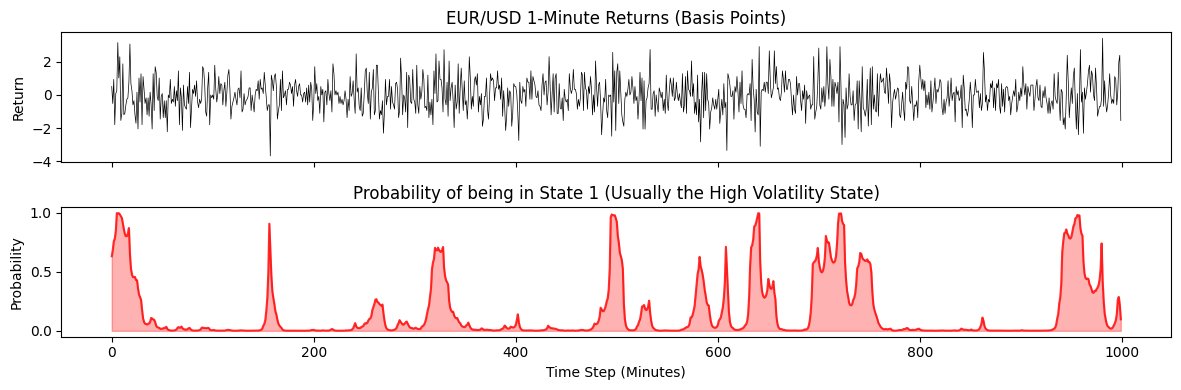

In [20]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings

# Ignore harmless convergence warnings
warnings.filterwarnings("ignore") 

# ==========================================
# 6. REAL DATA: EUR/USD TICK DATA
# ==========================================

# 1. Load the Parquet file (Using the BID file for this model)
file_path = '../data/processed/eurusd_dukascopy_bid_202601.parquet'
print(f"Loading data from {file_path}...")
df = pd.read_parquet(file_path)

# Ensure the datetime column is actually a datetime object and set it as the index
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# 2. Resample the data (CRITICAL FOR TICK DATA)
# Tick data has too many consecutive identical prices, causing 0.0 variance.
# We resample to 1-minute bars (taking the last price of each minute) to get clean returns.
print("Resampling tick data to 1-minute intervals...")
df_resampled = df['price'].resample('1min').last().dropna()

# 3. Calculate Log Returns
returns = np.log(df_resampled / df_resampled.shift(1)).dropna()

# 4. Clip the start and end of the day to avoid deterministic volatility
# Forex is 24/5, but let's isolate the core liquid hours (e.g., London/NY overlap)
print(f"Total 1-min observations before clipping: {len(returns)}")
returns_clipped = returns.between_time('09:00', '15:00').copy()
print(f"Total 1-min observations after clipping:  {len(returns_clipped)}")

# 5. Multiply returns by 10,000 (Convert to Basis Points)
# This prevents the optimizer from failing due to infinitely small decimals
y_real = returns_clipped * 10000 

# ==========================================
# FIT AR-HMM TO REAL DATA
# ==========================================
print("\nFitting 2-State AR(1) HMM to Real EUR/USD Data...")
print("This may take a minute or two depending on data size...")

# We use y_real.values to strip the datetime index. 
# This perfectly aligns with your supervisor's note: 
# "dette er ekvivalent med å tenke at dager er uavhengige"
real_model = sm.tsa.MarkovAutoregression(
    y_real.values, 
    k_regimes=2, 
    order=1, 
    trend='n', 
    switching_variance=True
)

real_result = real_model.fit()
print(real_result.summary())

# ==========================================
# VISUALIZE THE REGIMES
# ==========================================
# Plot a slice of the data to see the regime switching in action
# We'll just plot the first 1000 points so the chart isn't a solid block of ink

plot_limit = min(1000, len(y_real))

fig, axs = plt.subplots(2, 1, figsize=(12, 4), sharex=True)

# Plot the actual returns
axs[0].plot(y_real.values[:plot_limit], color='black', linewidth=0.5)
axs[0].set_title('EUR/USD 1-Minute Returns (Basis Points)')
axs[0].set_ylabel('Return')

# Plot the probability of being in State 1
axs[1].plot(real_result.smoothed_marginal_probabilities[:plot_limit, 1], color='red', alpha=0.8)
axs[1].fill_between(range(plot_limit), 0, real_result.smoothed_marginal_probabilities[:plot_limit, 1], color='red', alpha=0.3)
axs[1].set_title('Probability of being in State 1 (Usually the High Volatility State)')
axs[1].set_ylabel('Probability')
axs[1].set_xlabel('Time Step (Minutes)')

plt.tight_layout()
plt.show()

Fitting an AR(1) - ARCH(1) model to the real EUR/USD data...
                           AR - ARCH Model Results                            
Dep. Variable:                  price   R-squared:                       0.000
Mean Model:                        AR   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -11858.7
Distribution:                  Normal   AIC:                           23725.4
Method:            Maximum Likelihood   BIC:                           23753.1
                                        No. Observations:                 7579
Date:                Wed, Apr 08 2026   Df Residuals:                     7577
Time:                        21:35:01   Df Model:                            2
                                  Mean Model                                  
                  coef    std err          t      P>|t|       95.0% Conf. Int.
----------------------------------------------------------------------

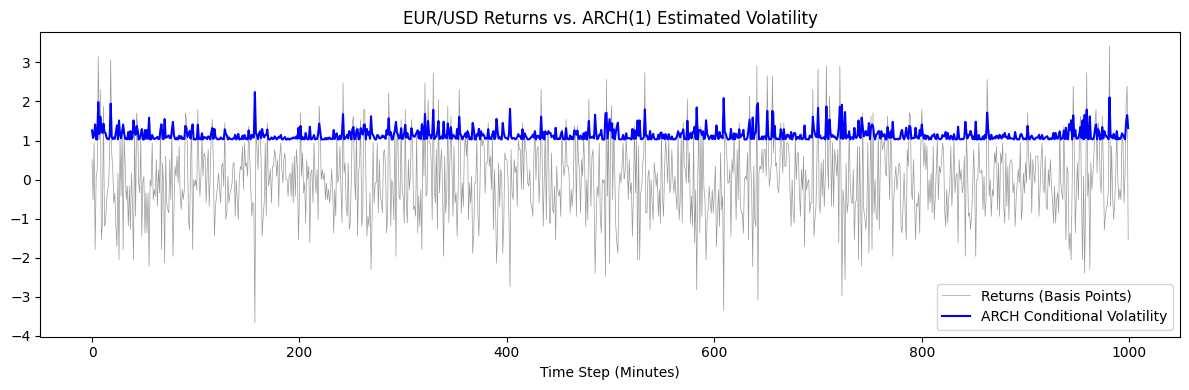

In [21]:
# ==========================================
# 7. EXPANDING TO AN ARCH MODEL
# ==========================================
from arch import arch_model
import matplotlib.pyplot as plt

print("Fitting an AR(1) - ARCH(1) model to the real EUR/USD data...")

# Fit the ARCH model
am = arch_model(y_real.dropna(), mean='AR', lags=1, vol='ARCH', p=1, rescale=False)
res_arch = am.fit(update_freq=5, disp='off')

print(res_arch.summary())

# ==========================================
# VISUALIZE VOLATILITY CLUSTERING (FIXED ALIGNMENT)
# ==========================================
fig, ax = plt.subplots(figsize=(12, 4))

# We use .values on BOTH to strip the datetime index, preventing the 1970 vs 2026 glitch
returns_to_plot = y_real.dropna().values[:plot_limit]
vol_to_plot = res_arch.conditional_volatility.dropna().values[:plot_limit]

# Plot the raw returns in the background
ax.plot(returns_to_plot, color='black', linewidth=0.5, alpha=0.4, label='Returns (Basis Points)')

# Plot the ARCH estimated conditional volatility over top
ax.plot(vol_to_plot, color='blue', linewidth=1.5, label='ARCH Conditional Volatility')

ax.set_title('EUR/USD Returns vs. ARCH(1) Estimated Volatility')
ax.set_xlabel('Time Step (Minutes)')
ax.legend()
plt.tight_layout()
plt.show()

Loading and aligning Asset Data...
Resampling to 1-minute grids...

Fitting Markov Regression to the Spread...
Finding the hidden structural means (beta_0)...
                        Markov Switching Model Results                        
Dep. Variable:                      y   No. Observations:                 7561
Model:               MarkovRegression   Log Likelihood               -1718.066
Date:                Wed, 08 Apr 2026   AIC                           3448.132
Time:                        21:43:34   BIC                           3489.717
Sample:                             0   HQIC                          3462.406
                               - 7561                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------

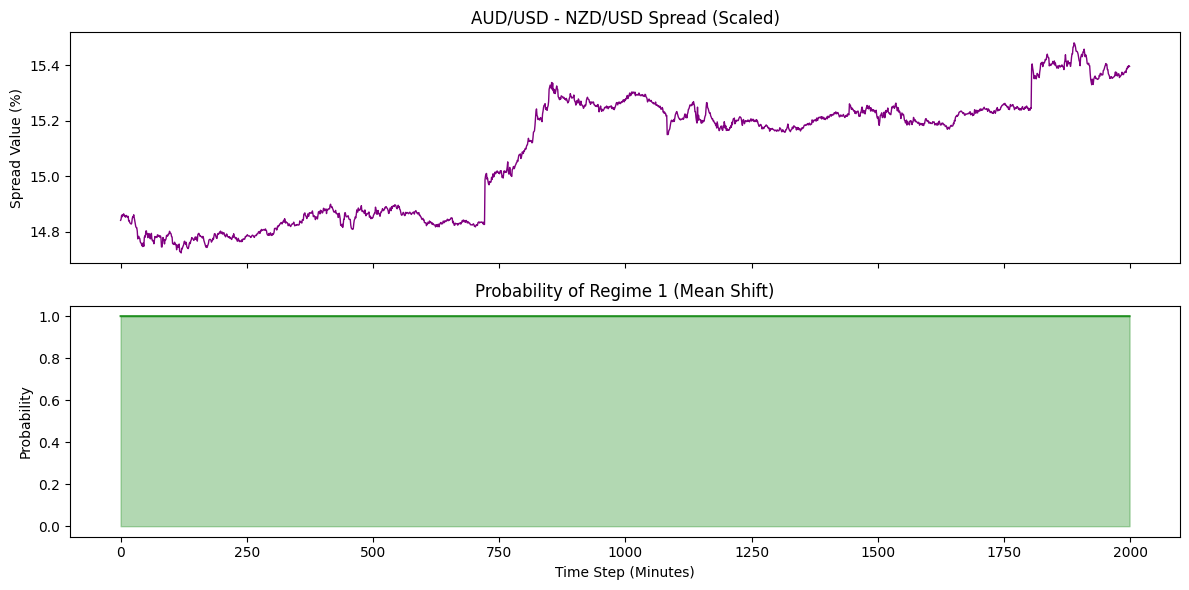

In [23]:
# ==========================================
# 8. PAIRS TRADING SPREAD (AUD/USD vs NZD/USD)
# ==========================================
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore") 

print("Loading and aligning Asset Data...")

# 1. Load the Parquet files
path_aud = '../data/processed/audusd_last_202601.parquet' 
path_nzd = '../data/processed/nzdusd_last_202601.parquet'

df_aud = pd.read_parquet(path_aud)
df_nzd = pd.read_parquet(path_nzd)

# 2. Ensure datetime index
df_aud['datetime'] = pd.to_datetime(df_aud['datetime'])
df_nzd['datetime'] = pd.to_datetime(df_nzd['datetime'])
df_aud.set_index('datetime', inplace=True)
df_nzd.set_index('datetime', inplace=True)

# 3. Resample both to 1-minute bars to align the timestamps
print("Resampling to 1-minute grids...")
aud_1m = df_aud['price'].resample('1min').last().dropna()
nzd_1m = df_nzd['price'].resample('1min').last().dropna()

# 4. Merge the two series together 
pair_df = pd.concat([aud_1m, nzd_1m], axis=1, join='inner')
pair_df.columns = ['AUDUSD', 'NZDUSD']

# Clip out the illiquid night hours
pair_df = pair_df.between_time('09:00', '15:00')

# 5. Calculate the Spread AND SCALE IT!
# Multiplying by 100 converts it to a percentage spread. 
# This prevents the LinAlgError by making the variances mathematically stable.
pair_df['Spread'] = (np.log(pair_df['AUDUSD']) - np.log(pair_df['NZDUSD'])) * 100

# ==========================================
# FIT HMM WITH SWITCHING INTERCEPT (beta_0)
# ==========================================
print("\nFitting Markov Regression to the Spread...")
print("Finding the hidden structural means (beta_0)...")

spread_model = sm.tsa.MarkovRegression(
    pair_df['Spread'].values, 
    k_regimes=2, 
    trend='c', 
    switching_trend=True, 
    switching_variance=True 
)

# Added search_reps=20 to ensure it doesn't get stuck in a bad math state
spread_result = spread_model.fit(disp=False, search_reps=20)
print(spread_result.summary())

# ==========================================
# VISUALIZE THE SPREAD REGIMES
# ==========================================
plot_limit = min(2000, len(pair_df))

fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Plot the Spread
axs[0].plot(pair_df['Spread'].values[:plot_limit], color='purple', linewidth=1)
axs[0].set_title('AUD/USD - NZD/USD Spread (Scaled)')
axs[0].set_ylabel('Spread Value (%)')

# Plot the probability of Regime 1
prob_regime_1 = spread_result.smoothed_marginal_probabilities[:plot_limit, 1]
axs[1].plot(prob_regime_1, color='green', alpha=0.8)
axs[1].fill_between(range(len(prob_regime_1)), 0, prob_regime_1, color='green', alpha=0.3)
axs[1].set_title('Probability of Regime 1 (Mean Shift)')
axs[1].set_ylabel('Probability')
axs[1].set_xlabel('Time Step (Minutes)')

plt.tight_layout()
plt.show()

AUD raw ticks: 1,346,176
NZD raw ticks: 1,168,903

AUD columns: ['datetime', 'symbol', 'price_type', 'price', 'volume']
AUD dtypes:
datetime      datetime64[ns, UTC]
symbol                     object
price_type                 object
price                     float64
volume                    float64
dtype: object

                          datetime  symbol price_type    price  volume
0 2025-12-31 20:00:00.831000+00:00  AUDUSD        ASK  0.66731     1.2
1 2025-12-31 20:00:01.867000+00:00  AUDUSD        ASK  0.66730     1.2
2 2025-12-31 20:00:02.076000+00:00  AUDUSD        ASK  0.66731     1.2
3 2025-12-31 20:00:03.859000+00:00  AUDUSD        ASK  0.66730     1.2
4 2025-12-31 20:00:05.863000+00:00  AUDUSD        ASK  0.66729     1.2

Aligned active-market bars: 29,802
Gaps > 5 min (weekends/sessions): 5
  Largest gap: 2 days 00:06:00
  Example gaps:
datetime
2026-01-01 22:04:00+00:00   1 days 00:06:00
2026-01-04 22:02:00+00:00   2 days 00:03:00
2026-01-11 22:05:00+00:00   2 days 00:06:

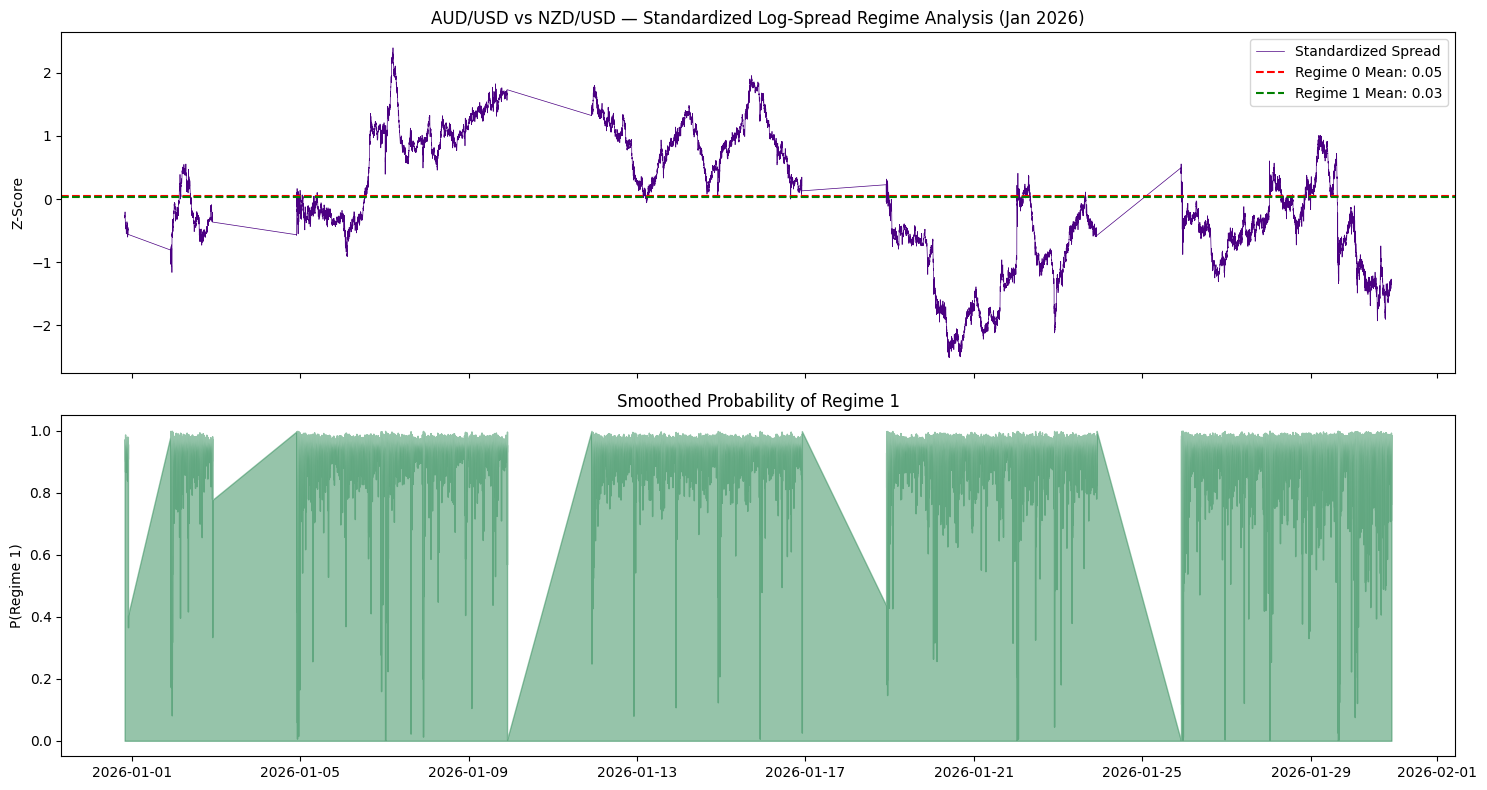


Saved: regime_analysis.png


In [34]:
# ==========================================
# 10. ULTRA-STABLE PAIRS REGIME MODEL
# ==========================================
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pathlib import Path

# ==========================================
# 1. LOAD AND ALIGN TICK DATA
# ==========================================
DATA_DIR = Path('../data/processed/')

aud = pd.read_parquet(DATA_DIR / 'audusd_dukascopy_ask_202601.parquet')
nzd = pd.read_parquet(DATA_DIR / 'nzdusd_dukascopy_ask_202601.parquet')

print(f"AUD raw ticks: {len(aud):,}")
print(f"NZD raw ticks: {len(nzd):,}")
print(f"\nAUD columns: {aud.columns.tolist()}")
print(f"AUD dtypes:\n{aud.dtypes}\n")
print(aud.head())

# ==========================================
# 1b. RESAMPLE TO COMMON FREQUENCY
# ==========================================
# Tick data won't align 1:1 — resample to 1-minute bars (last price)
# using the 'datetime' column as the index

aud = aud.set_index('datetime').sort_index()
nzd = nzd.set_index('datetime').sort_index()

aud_1m = aud['price'].resample('1min').last()
nzd_1m = nzd['price'].resample('1min').last()

# Inner join — only keeps minutes where BOTH assets had at least one tick.
# This naturally clips off-hours, weekends, and holidays because no ticks = NaN = dropped.
pair_df = pd.DataFrame({
    'Asset_A': aud_1m,   # AUD/USD
    'Asset_B': nzd_1m,   # NZD/USD
}).dropna()

# Additionally, remove any bars where price didn't change in BOTH assets
# (stale quote carry-forward from very thin liquidity windows)
aud_changed = pair_df['Asset_A'].diff().ne(0)
nzd_changed = pair_df['Asset_B'].diff().ne(0)
either_moved = aud_changed | nzd_changed
# Keep the first row (diff is NaN) plus any row where at least one asset moved
pair_df = pair_df[either_moved | (pair_df.index == pair_df.index[0])]

# Verify no large time gaps remain (sanity check)
time_gaps = pair_df.index.to_series().diff()
large_gaps = time_gaps[time_gaps > pd.Timedelta(minutes=5)]
print(f"\nAligned active-market bars: {len(pair_df):,}")
print(f"Gaps > 5 min (weekends/sessions): {len(large_gaps)}")
if len(large_gaps) > 0:
    print(f"  Largest gap: {large_gaps.max()}")
    print(f"  Example gaps:\n{large_gaps.head(5)}")
print(pair_df.head())

if len(pair_df) < 100:
    raise ValueError(f"Only {len(pair_df)} aligned bars — check data overlap / timezone handling.")

# ==========================================
# 2. Z-SCORE STANDARDIZATION
# ==========================================
raw_log_spread = np.log(pair_df['Asset_A']) - np.log(pair_df['Asset_B'])

spread_mean = raw_log_spread.mean()
spread_std = raw_log_spread.std()

if spread_std < 1e-10:
    raise ValueError(f"Spread std is ~0 ({spread_std}). Assets may be identical.")

pair_df['Spread_Standardized'] = (raw_log_spread - spread_mean) / spread_std

print(f"\nStandardization Complete.")
print(f"  Raw spread  — Mean: {spread_mean:.6f}, Std: {spread_std:.6f}")
print(f"  Standardized — Mean: {pair_df['Spread_Standardized'].mean():.4f}, "
      f"Std: {pair_df['Spread_Standardized'].std():.4f}")

# ==========================================
# 3. FIT MARKOV AUTOREGRESSION
# ==========================================
print("\nFitting Markov Autoregression (Standardized + Known Init)...")

spread_values = pair_df['Spread_Standardized'].dropna().values

model = sm.tsa.MarkovAutoregression(
    spread_values,
    k_regimes=2,
    order=1,
    trend='c',
    switching_trend=True,
    switching_variance=False,
)

# statsmodels 0.14.x: set initialization AFTER construction, not via constructor kwargs
model.initialize_known([0.5, 0.5])

try:
    result = model.fit(em_iter=0, method='bfgs', disp=False)
except Exception as e:
    print(f"bfgs failed ({e}), falling back to powell...")
    result = model.fit(em_iter=0, method='powell', disp=False)

print(result.summary())

# ==========================================
# 4. EXTRACT REGIME MEANS SAFELY
# ==========================================
# result.params may be a numpy array (not a Series) depending on statsmodels version
param_names = model.param_names
params = np.array(result.params)  # ensure plain array
print("\nParameter names:", param_names)
print("Parameter values:", params)

# Find the indices of the regime constants
const_indices = [i for i, n in enumerate(param_names) if 'const' in n.lower()]

if len(const_indices) >= 2:
    c0 = params[const_indices[0]]
    c1 = params[const_indices[1]]
else:
    print("WARNING: Could not find regime constants by name, using summary values.")
    # From your summary output: Regime 0 const is first, Regime 1 const is second
    c0 = params[0]
    c1 = params[1]

print(f"\nRegime 0 mean (standardized): {c0:.4f}")
print(f"Regime 1 mean (standardized): {c1:.4f}")
print(f"Regime 0 mean (original log-spread): {c0 * spread_std + spread_mean:.6f}")
print(f"Regime 1 mean (original log-spread): {c1 * spread_std + spread_mean:.6f}")

# ==========================================
# 5. VISUALIZE
# ==========================================
fig, axs = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Use the datetime index for the x-axis
# Ensure all arrays share the same length (AR(1) drops the first observation)
prob_state_1 = result.smoothed_marginal_probabilities[:, 1]
n_obs = len(prob_state_1)
idx = pair_df.dropna(subset=['Spread_Standardized']).index[-n_obs:]
plot_spread = spread_values[-n_obs:]

axs[0].plot(idx, plot_spread, color='indigo', linewidth=0.5, label='Standardized Spread')
axs[0].axhline(c0, color='red', linestyle='--', label=f'Regime 0 Mean: {c0:.2f}')
axs[0].axhline(c1, color='green', linestyle='--', label=f'Regime 1 Mean: {c1:.2f}')
axs[0].set_title('AUD/USD vs NZD/USD — Standardized Log-Spread Regime Analysis (Jan 2026)')
axs[0].set_ylabel('Z-Score')
axs[0].legend()

axs[1].fill_between(idx, 0, prob_state_1, color='seagreen', alpha=0.5)
axs[1].set_title('Smoothed Probability of Regime 1')
axs[1].set_ylabel('P(Regime 1)')
axs[1].set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig('regime_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: regime_analysis.png")